# Google (GOOG) Stock Price Forecasting with LSTM

Practical Project – Sequence Modelling using TensorFlow/Keras

## Project Overview
- Download historical Google stock data from Yahoo Finance
- Prepare sequence data for deep learning
- Train an LSTM network
- Evaluate forecasting accuracy
- Compare predicted and actual prices

In [1]:

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data source
import yfinance as yf

# Machine learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

np.random.seed(42)
tf.random.set_seed(42)


## Download Data

In [2]:

ticker = "GOOG"

data = yf.download(
    ticker,
    start="2004-08-19",   # earliest Google trading data
    end=None,
    auto_adjust=True
)[["Close"]]

data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,GOOG
Date,
2004-08-19,2.478782
2004-08-20,2.675672
2004-08-23,2.702599
2004-08-24,2.590691
2004-08-25,2.618605


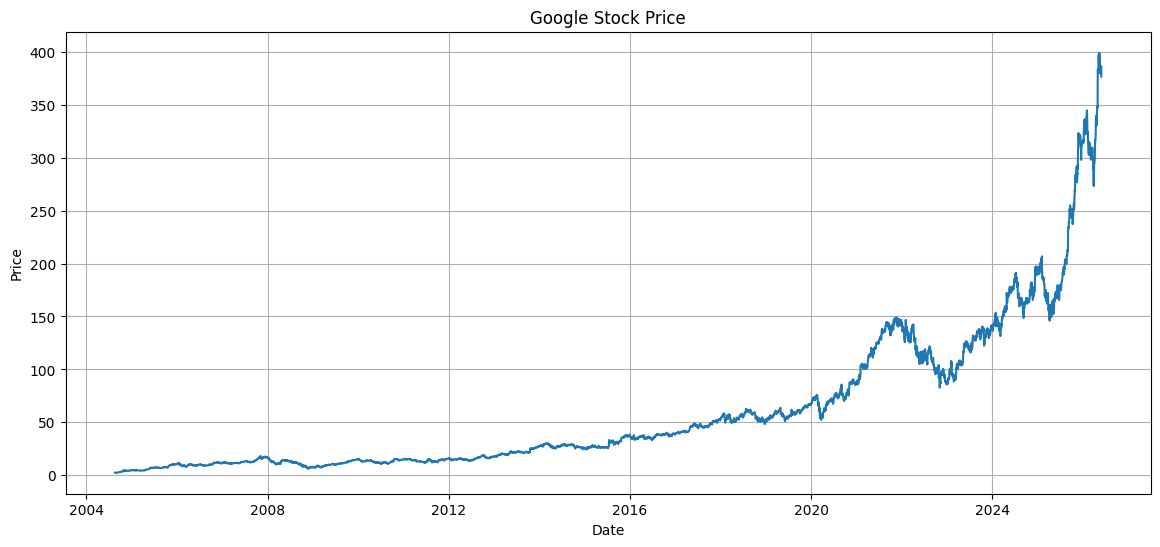

In [3]:

plt.figure(figsize=(14,6))
plt.plot(data.index, data["Close"])
plt.title("Google Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


## Train/Test Split and Scaling

In [4]:

train_data, test_data = train_test_split(
    data,
    train_size=0.80,
    shuffle=False
)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(train_scaled.shape, test_scaled.shape)


(4383, 1) (1096, 1)


## Sequence Construction

In [5]:

sequence_length = 60

train_generator = TimeseriesGenerator(
    train_scaled,
    train_scaled,
    length=sequence_length,
    batch_size=32
)

test_generator = TimeseriesGenerator(
    test_scaled,
    test_scaled,
    length=sequence_length,
    batch_size=32
)

x_batch, y_batch = train_generator[0]
print(x_batch.shape, y_batch.shape)


(32, 60, 1) (32, 1)


## LSTM Model

In [6]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(sequence_length,1)),
    tf.keras.layers.LSTM(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [7]:

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    train_generator,
    epochs=100,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0019    
Epoch 2/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0030
Epoch 3/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0019
Epoch 4/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0024
Epoch 5/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0027
Epoch 6/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0022
Epoch 7/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0025
Epoch 8/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0015
Epoch 9/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0014    
Epoch 10/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0012    
Epoch 11/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0013    
Epoch 12/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0011    
Epoch 13/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0012    
Epoch 14/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0010    
E

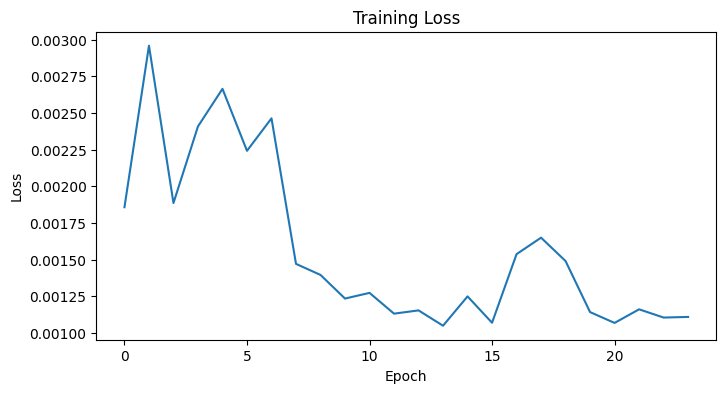

In [8]:

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


## Forecasting Performance

In [9]:

predictions = model.predict(test_generator)

predictions_rescaled = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(test_scaled[sequence_length:])

rmse = np.sqrt(mean_squared_error(actual, predictions_rescaled))
r2 = r2_score(actual, predictions_rescaled)

print("RMSE:", round(rmse,4))
print("R²:", round(r2,4))


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
RMSE: 9.3724
R²: 0.9831


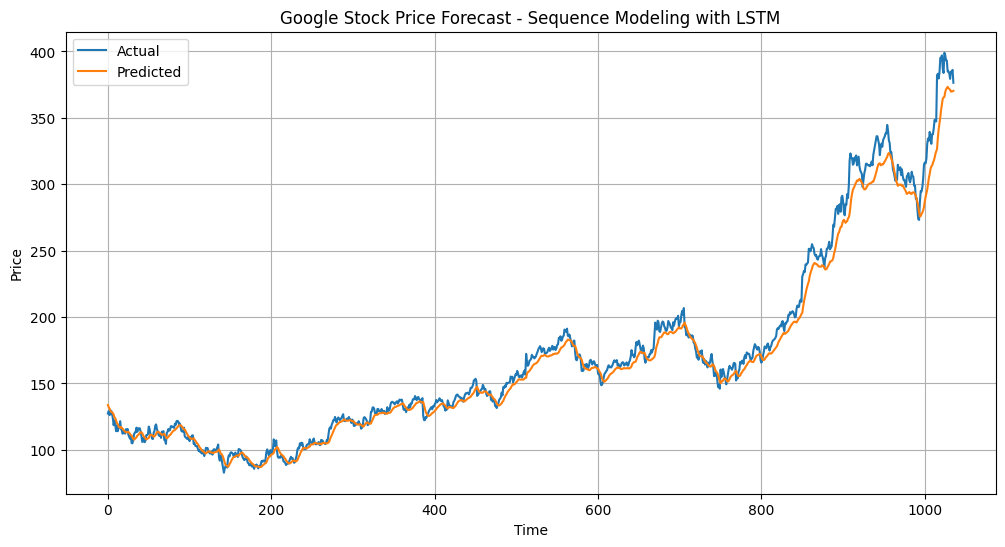

In [11]:

plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual")
plt.plot(predictions_rescaled, label="Predicted")

plt.title("Google Stock Price Forecast - Sequence Modeling with LSTM")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()


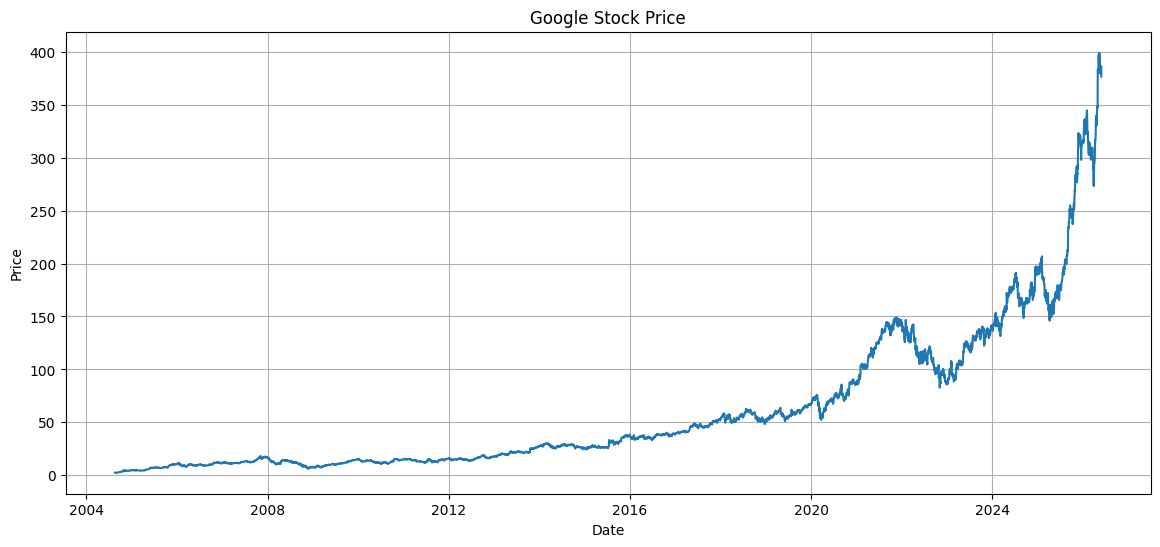

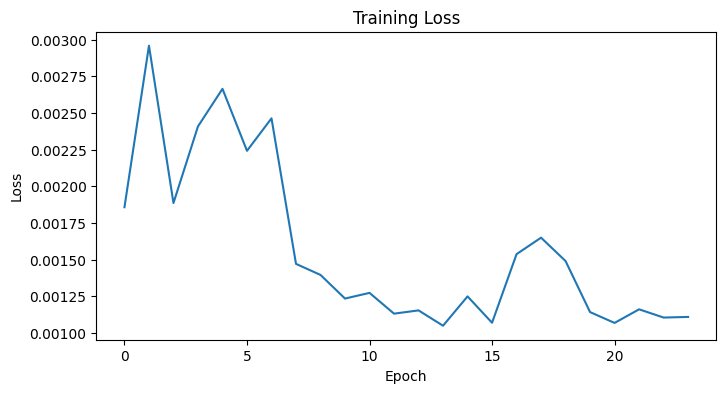

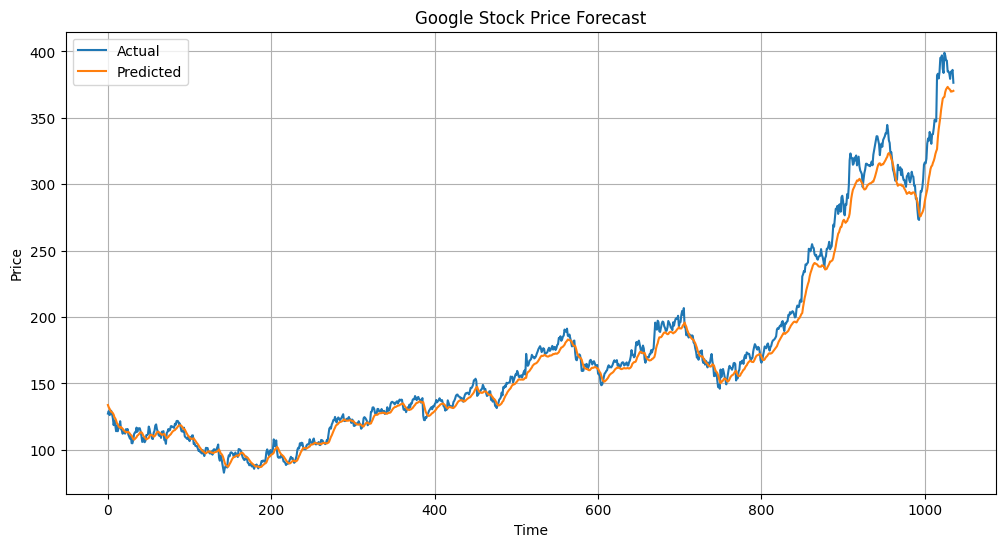

All figures saved in images/
Model saved in saved_models/


In [12]:
# ==========================================
# SAVE FIGURES AND TRAINED MODEL
# ==========================================

import os

os.makedirs("images", exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

# ------------------------------------------
# Figure 1: Historical Stock Price
# ------------------------------------------

plt.figure(figsize=(14,6))
plt.plot(data.index, data["Close"])
plt.title("Google Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.savefig(
    "images/google_stock_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------
# Figure 2: Training Loss
# ------------------------------------------

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(
    "images/training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------
# Figure 3: Actual vs Predicted
# ------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual")
plt.plot(predictions_rescaled, label="Predicted")

plt.title("Google Stock Price Forecast")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.savefig(
    "images/forecast_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------
# Save Trained Model
# ------------------------------------------

model.save(
    "saved_models/google_lstm_model.keras"
)

print("All figures saved in images/")
print("Model saved in saved_models/")

## Project Notes
This notebook reproduces a sequence modelling workflow using LSTM networks on Google stock prices obtained from Yahoo Finance. The objective is to evaluate the ability of recurrent neural networks to learn temporal patterns from historical market data and generate one-step-ahead forecasts.